In [1]:
import pandas as pd

In [2]:
columns = ['ca_chi', 't_pop', 'age_5', 'edu_dip', 'edu_sub', 'edu_deg',
           'dhi_1', 'dhi_2', 'dhi_3', 'dhi_4', 'dhi_5', 'dhi_6', 'dhi_7', 'Shape_Area']
data_2021 = pd.read_excel('2021_statistics.xls', usecols = columns)
data_static = pd.read_excel('Noise_NDVI_Density_Mixture.xlsx', usecols = ['ca_chi', 'Shannon_In', 'density', 'NDVI', 'Noise', 'Building_type'])

In [3]:
clean_2021 = data_2021.copy()
clean_2021.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age_5       215 non-null    int64  
 1   ca_chi      215 non-null    object 
 2   dhi_1       215 non-null    int64  
 3   dhi_2       215 non-null    int64  
 4   dhi_3       215 non-null    int64  
 5   dhi_4       215 non-null    int64  
 6   dhi_5       215 non-null    int64  
 7   dhi_6       215 non-null    int64  
 8   dhi_7       215 non-null    int64  
 9   edu_deg     215 non-null    int64  
 10  edu_dip     215 non-null    int64  
 11  edu_sub     215 non-null    int64  
 12  t_pop       215 non-null    int64  
 13  Shape_Area  215 non-null    float64
dtypes: float64(1), int64(12), object(1)
memory usage: 23.6+ KB


In [4]:
clean_static = data_static.copy()
clean_static.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ca_chi         215 non-null    object 
 1   Shannon_In     215 non-null    float64
 2   density        215 non-null    float64
 3   NDVI           215 non-null    float64
 4   Noise          215 non-null    float64
 5   Building_type  215 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 10.2+ KB


In [5]:
from scipy.stats import lognorm 
import numpy as np

# 定义生成收入数据的函数
def generate_income(low, high, count, sigma=0.5):
    generate_data = []
    while len(generate_data) < count:
        new_data = lognorm.rvs(s=sigma, scale=(low + high) / 2, size=count)
        new_data = new_data[(new_data >= low) & (new_data <= high)]
        generate_data.extend(new_data)
        generate_data = generate_data[:count]
    return np.array(generate_data)

# 定义基尼指数计算函数
def gini_coefficient(income_array):
    sorted_array = np.sort(income_array)
    n = len(income_array)
    cumulative_values = np.cumsum(sorted_array) / np.sum(sorted_array)
    cumulative_index = np.arange(1, n + 1) / n
    gini_index = 1 - 2 * np.trapz(cumulative_values, cumulative_index)
    return gini_index

# 定义计算基尼指数的主函数
def calculate_dataframe(df, income_columns, income_intervals, new_column_name="Gini", sigma=0.5):
    """
    - income_columns: 与收入区间对应的列名列表
    - income_intervals: 收入区间的列表，例如 [(1000, 6000), (6000, 10000), ...]
    - new_column_name: 新列名，存放基尼指数
    - sigma: 对数正态分布的标准差，默认 0.5
    """
    gini_values = []  # 存储每个区域的基尼指数

    for index, row in df.iterrows():
        income_data = []
        for (low, high), column_name in zip(income_intervals, income_columns):
            count = int(row[column_name])
            if count > 0:  # 如果人数大于 0，则生成收入数据
                income_data.extend(generate_income(low, high, count, sigma))
        
        income_data = np.array(income_data)
        gini = gini_coefficient(income_data) if len(income_data) > 0 else 0  # 避免空数据报错
        gini_values.append(gini)

    # 将基尼指数添加到 DataFrame
    df[new_column_name] = gini_values

    # 计算人口密度
    df['Pop_den'] = df['t_pop'] / df['Shape_Area']
    
    # 65岁以上人口占总人口的比例
    df['Above65'] = df['age_5'] / df['t_pop']
    
    # 高中以上教育程度人口比例
    df['Edu'] = df[['edu_dip', 'edu_sub', 'edu_deg']].sum(axis=1) / df['t_pop']
    
    return df[['ca_chi', 'Gini', 'Pop_den', 'Above65',  'Edu']]

In [6]:
income_intervals = [(1000, 6000), (6000, 10000), (10000, 20000), (20000, 30000), (30000, 40000), (40000, 60000), (60000, 150000)]
income_columns = ['dhi_1', 'dhi_2', 'dhi_3', 'dhi_4', 'dhi_5', 'dhi_6', 'dhi_7']
final_2021 = calculate_dataframe(clean_2021, income_columns, income_intervals)

In [7]:
final_2021

,ca_chi,Gini,Pop_den,Above65,Edu
0,中環,0.438239,0.006609,0.197707,0.529475
1,半山東,0.393124,0.046612,0.194646,0.572232
2,衛城,0.301773,0.070177,0.145547,0.582655
3,山頂,0.288215,0.003346,0.114571,0.573899
4,大學,0.357819,0.012136,0.200183,0.541622
...,...,...,...,...,...
210,康樂,0.484283,0.087889,0.207956,0.318062
211,定安,0.451795,0.191365,0.254959,0.197414
212,牛頭角上邨,0.472334,0.201528,0.299494,0.175173
213,牛頭角下邨,0.475986,0.084359,0.216947,0.225022


In [8]:
appearance_colomn = ['CNAME', 'new_beauti', 'new_boring', 'new_depres', 'new_lively', 'new_safety', 'new_wealth']
app_data = pd.read_excel('Appearance_Scores.xls', usecols = appearance_colomn)
app_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CNAME       215 non-null    object 
 1   new_beauti  215 non-null    float64
 2   new_boring  215 non-null    float64
 3   new_depres  215 non-null    float64
 4   new_lively  215 non-null    float64
 5   new_safety  215 non-null    float64
 6   new_wealth  215 non-null    float64
dtypes: float64(6), object(1)
memory usage: 11.9+ KB


In [9]:
app_data = app_data.rename(columns = {'CNAME': 'ca_chi'})
app_data['App'] = app_data[['new_beauti', 'new_lively', 'new_safety', 'new_wealth']].sum(axis=1) - app_data[['new_boring', 'new_depres']].sum(axis = 1)
clean_app = app_data[['ca_chi', 'App']]
clean_app

,ca_chi,App
0,小西灣,24.583309
1,翠德,32.956466
2,漁灣,37.595711
3,翡翠,35.115183
4,景怡,34.056369
...,...,...
210,半山東,35.120519
211,衛城,33.502246
212,大學,31.961329
213,水街,31.716019


In [10]:
temp = pd.merge(final_2021, clean_static, how = 'inner', on = 'ca_chi')
result = pd.merge(temp, clean_app, how = 'inner', on = 'ca_chi')
result

,ca_chi,Gini,Pop_den,Above65,Edu,Shannon_In,density,NDVI,Noise,Building_type,App
0,中環,0.438239,0.006609,0.197707,0.529475,1.139638,0.572897,0.074682,68.784591,0,28.659053
1,半山東,0.393124,0.046612,0.194646,0.572232,1.479580,0.483929,0.130610,60.171691,0,35.120519
2,衛城,0.301773,0.070177,0.145547,0.582655,1.255723,0.509847,0.121225,52.584754,0,33.502246
3,山頂,0.288215,0.003346,0.114571,0.573899,0.933609,0.103192,0.470087,48.879869,0,36.543938
4,大學,0.357819,0.012136,0.200183,0.541622,0.771217,0.167103,0.482418,51.675865,0,31.961329
...,...,...,...,...,...,...,...,...,...,...,...
210,康樂,0.484283,0.087889,0.207956,0.318062,1.512525,0.449208,0.100374,58.514463,0,29.416776
211,定安,0.451795,0.191365,0.254959,0.197414,1.516649,0.354524,0.026834,64.645365,1,25.854578
212,牛頭角上邨,0.472334,0.201528,0.299494,0.175173,1.569292,0.773880,0.060932,63.453213,1,28.298021
213,牛頭角下邨,0.475986,0.084359,0.216947,0.225022,1.594514,1.031249,0.091880,70.779702,1,29.689565


In [11]:
result.describe()

,Gini,Pop_den,Above65,Edu,Shannon_In,density,NDVI,Noise,Building_type,App
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000
mean,0.443974,0.079630,0.214561,0.322109,1.335526,0.506618,0.147804,63.023966,0.437209,30.159814
std,0.045046,0.053807,0.048880,0.119725,0.265614,0.401765,0.140260,7.089266,0.497199,5.068333
min,0.288215,0.001000,0.061991,0.146071,0.487885,0.003535,0.000000,40.796453,0.000000,11.851425
25%,0.429290,0.039337,0.183494,0.216958,1.169805,0.298151,0.043564,59.292927,0.000000,27.077411
50%,0.452446,0.076746,0.215564,0.299742,1.377264,0.431829,0.103280,64.087465,0.000000,30.575107
75%,0.474909,0.111283,0.247665,0.417569,1.515832,0.592412,0.219892,68.351673,1.000000,33.285599
max,0.516380,0.286904,0.337321,0.582655,1.938064,2.890564,0.737839,75.206121,1.000000,44.772084


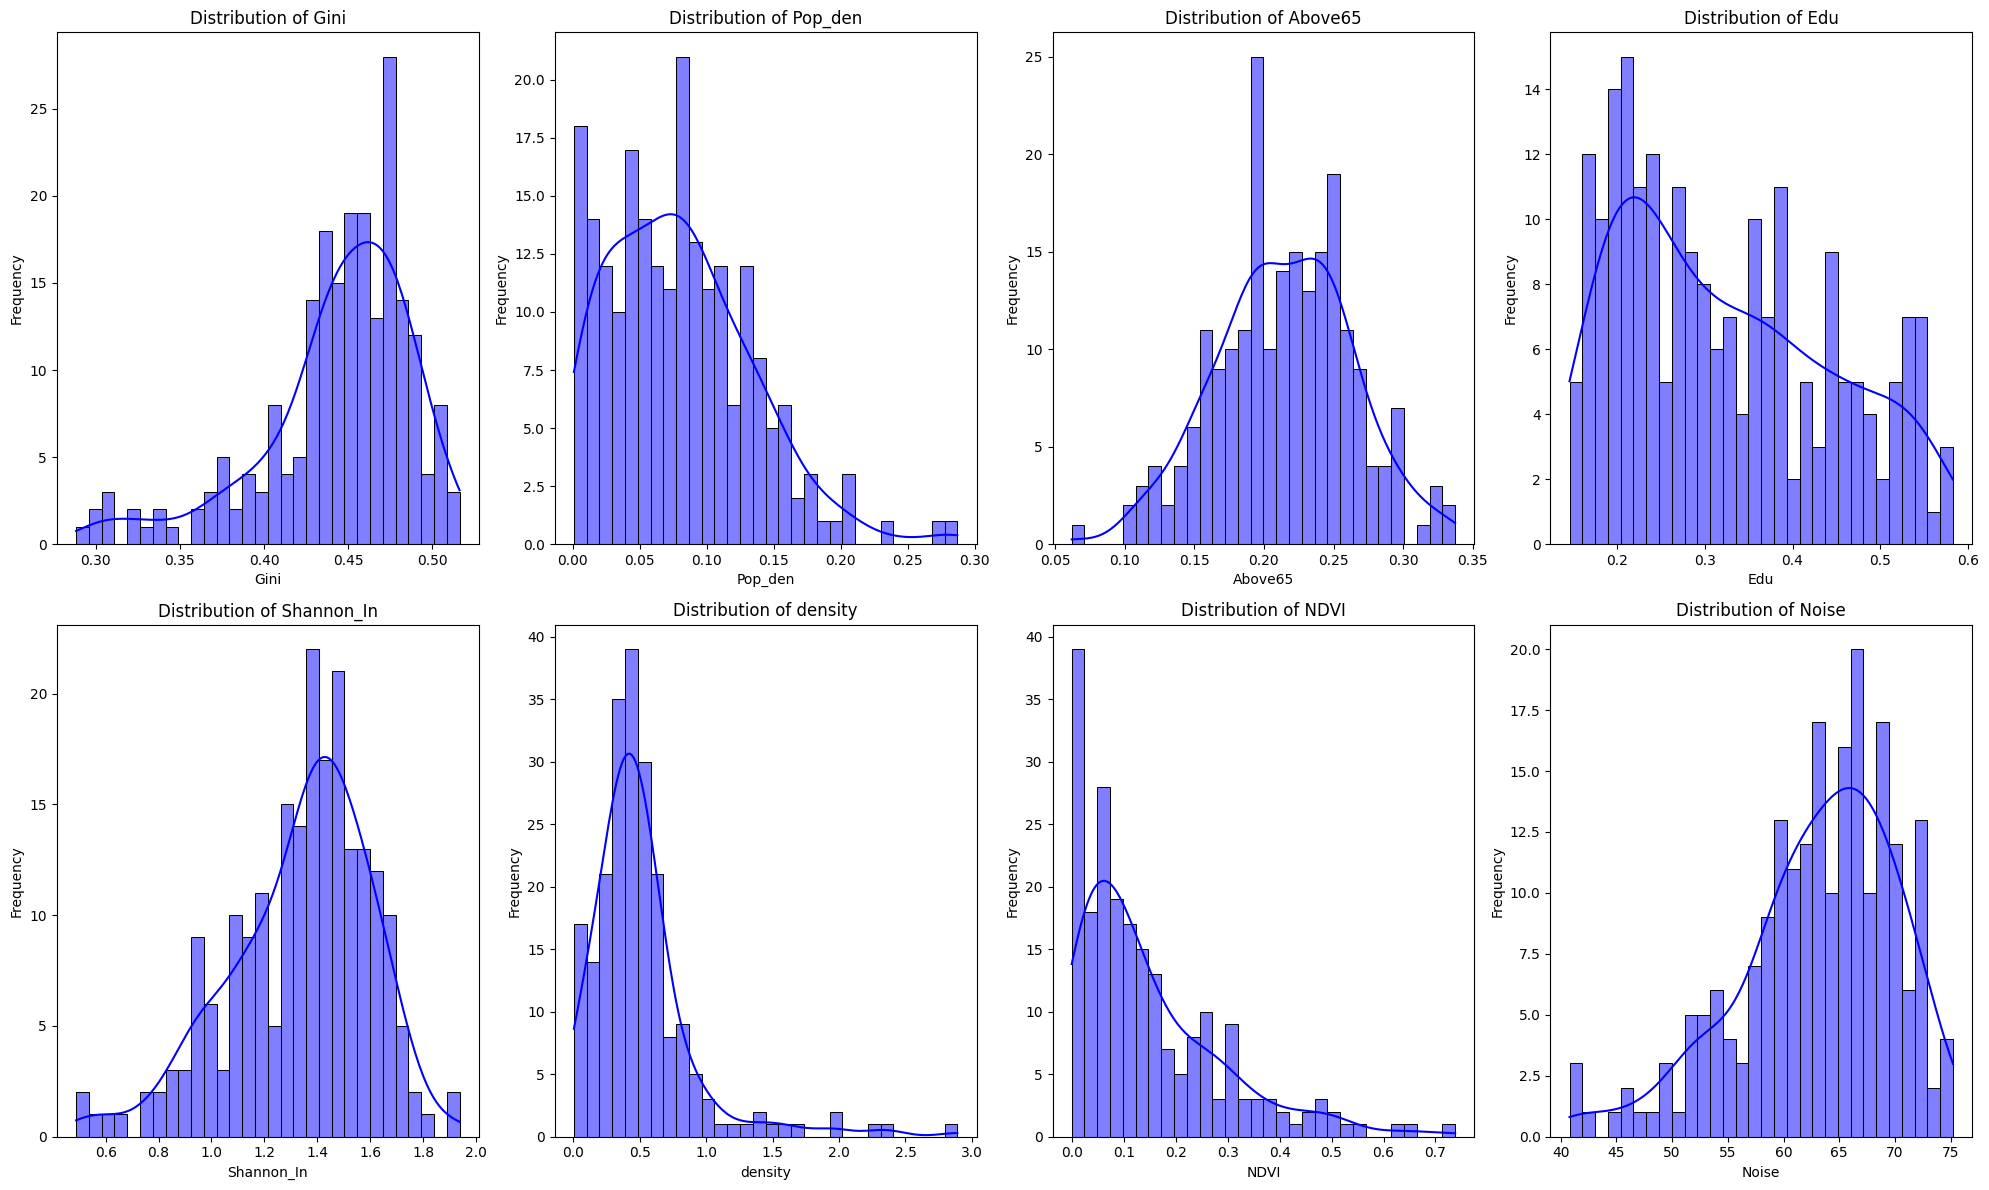

             Gini     Pop_den     Above65         Edu  Shannon_In     density  \
count  215.000000  215.000000  215.000000  215.000000  215.000000  215.000000   
mean     0.443974    0.079630    0.214561    0.322109    1.335526    0.506618   
std      0.045046    0.053807    0.048880    0.119725    0.265614    0.401765   
min      0.288215    0.001000    0.061991    0.146071    0.487885    0.003535   
25%      0.429290    0.039337    0.183494    0.216958    1.169805    0.298151   
50%      0.452446    0.076746    0.215564    0.299742    1.377264    0.431829   
75%      0.474909    0.111283    0.247665    0.417569    1.515832    0.592412   
max      0.516380    0.286904    0.337321    0.582655    1.938064    2.890564   

             NDVI       Noise  
count  215.000000  215.000000  
mean     0.147804   63.023966  
std      0.140260    7.089266  
min      0.000000   40.796453  
25%      0.043564   59.292927  
50%      0.103280   64.087465  
75%      0.219892   68.351673  
max      0.737

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# 查看各变量的分布
variables = ['Gini', 'Pop_den', 'Above65', 'Edu',  'Shannon_In', 'density', 'NDVI', 'Noise']

rows = 2
cols = 4

fig, axes = plt.subplots(rows, cols, figsize = (20, 12))
axes = axes.flatten()

for i, var in enumerate(variables):
    sns.histplot(result[var], kde = True, bins = 30, color = 'blue', ax = axes[i])
    axes[i].set_title(f'Distribution of {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frequency')

for i in range(len(variables), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# 描述性统计
print(result[variables].describe())

In [13]:
result['Building_type'] = result['Building_type'].astype('category')

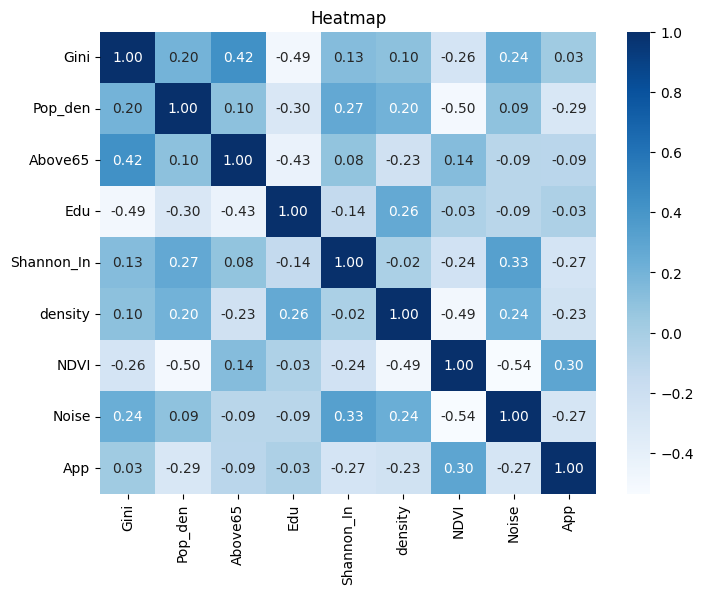

In [14]:
# 提取相关性分析所需的列
columns_to_analyze = ['Gini', 'Pop_den', 'Above65', 'Edu',  'Shannon_In', 'density', 'NDVI', 'Noise', 'App']
subset = result[columns_to_analyze]

# 计算相关系数矩阵
correlation_matrix = subset.corr()

# 可视化相关性矩阵
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="Blues", fmt=".2f")
plt.title("Heatmap")
plt.savefig('Heatmap2021.png', dpi=300) 
plt.show()


In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# 提取自变量
X_VIF = result[['Gini', 'Pop_den', 'Above65', 'Edu',  'Shannon_In', 'density', 'NDVI', 'Noise']]

# 保存变量名
feature_names = X_VIF.columns.tolist()

# 标准化自变量
scaler = StandardScaler()
X_VIF_scaled = scaler.fit_transform(X_VIF)

# 添加常数项
X_VIF_const = sm.add_constant(X_VIF_scaled)  # 返回 NumPy 数组

# 将 NumPy 数组转换回 DataFrame，并恢复列名
X_VIF_const = pd.DataFrame(X_VIF_const, columns=["const"] + feature_names)

# 计算 VIF
vif = pd.DataFrame()
vif["Variable"] = X_VIF_const.columns
vif["VIF"] = [variance_inflation_factor(X_VIF_const.values, i) for i in range(X_VIF_const.shape[1])]

print(vif)

     Variable       VIF
0       const  1.000000
1        Gini  1.763012
2     Pop_den  1.860067
3     Above65  1.463311
4         Edu  1.885302
5  Shannon_In  1.241155
6     density  1.525065
7        NDVI  2.637501
8       Noise  1.749390


所有变量的 方差膨胀因子 (VIF) 值均在 1-2 范围内。这是一个非常好的结果，说明自变量之间不存在严重的多重共线性问题

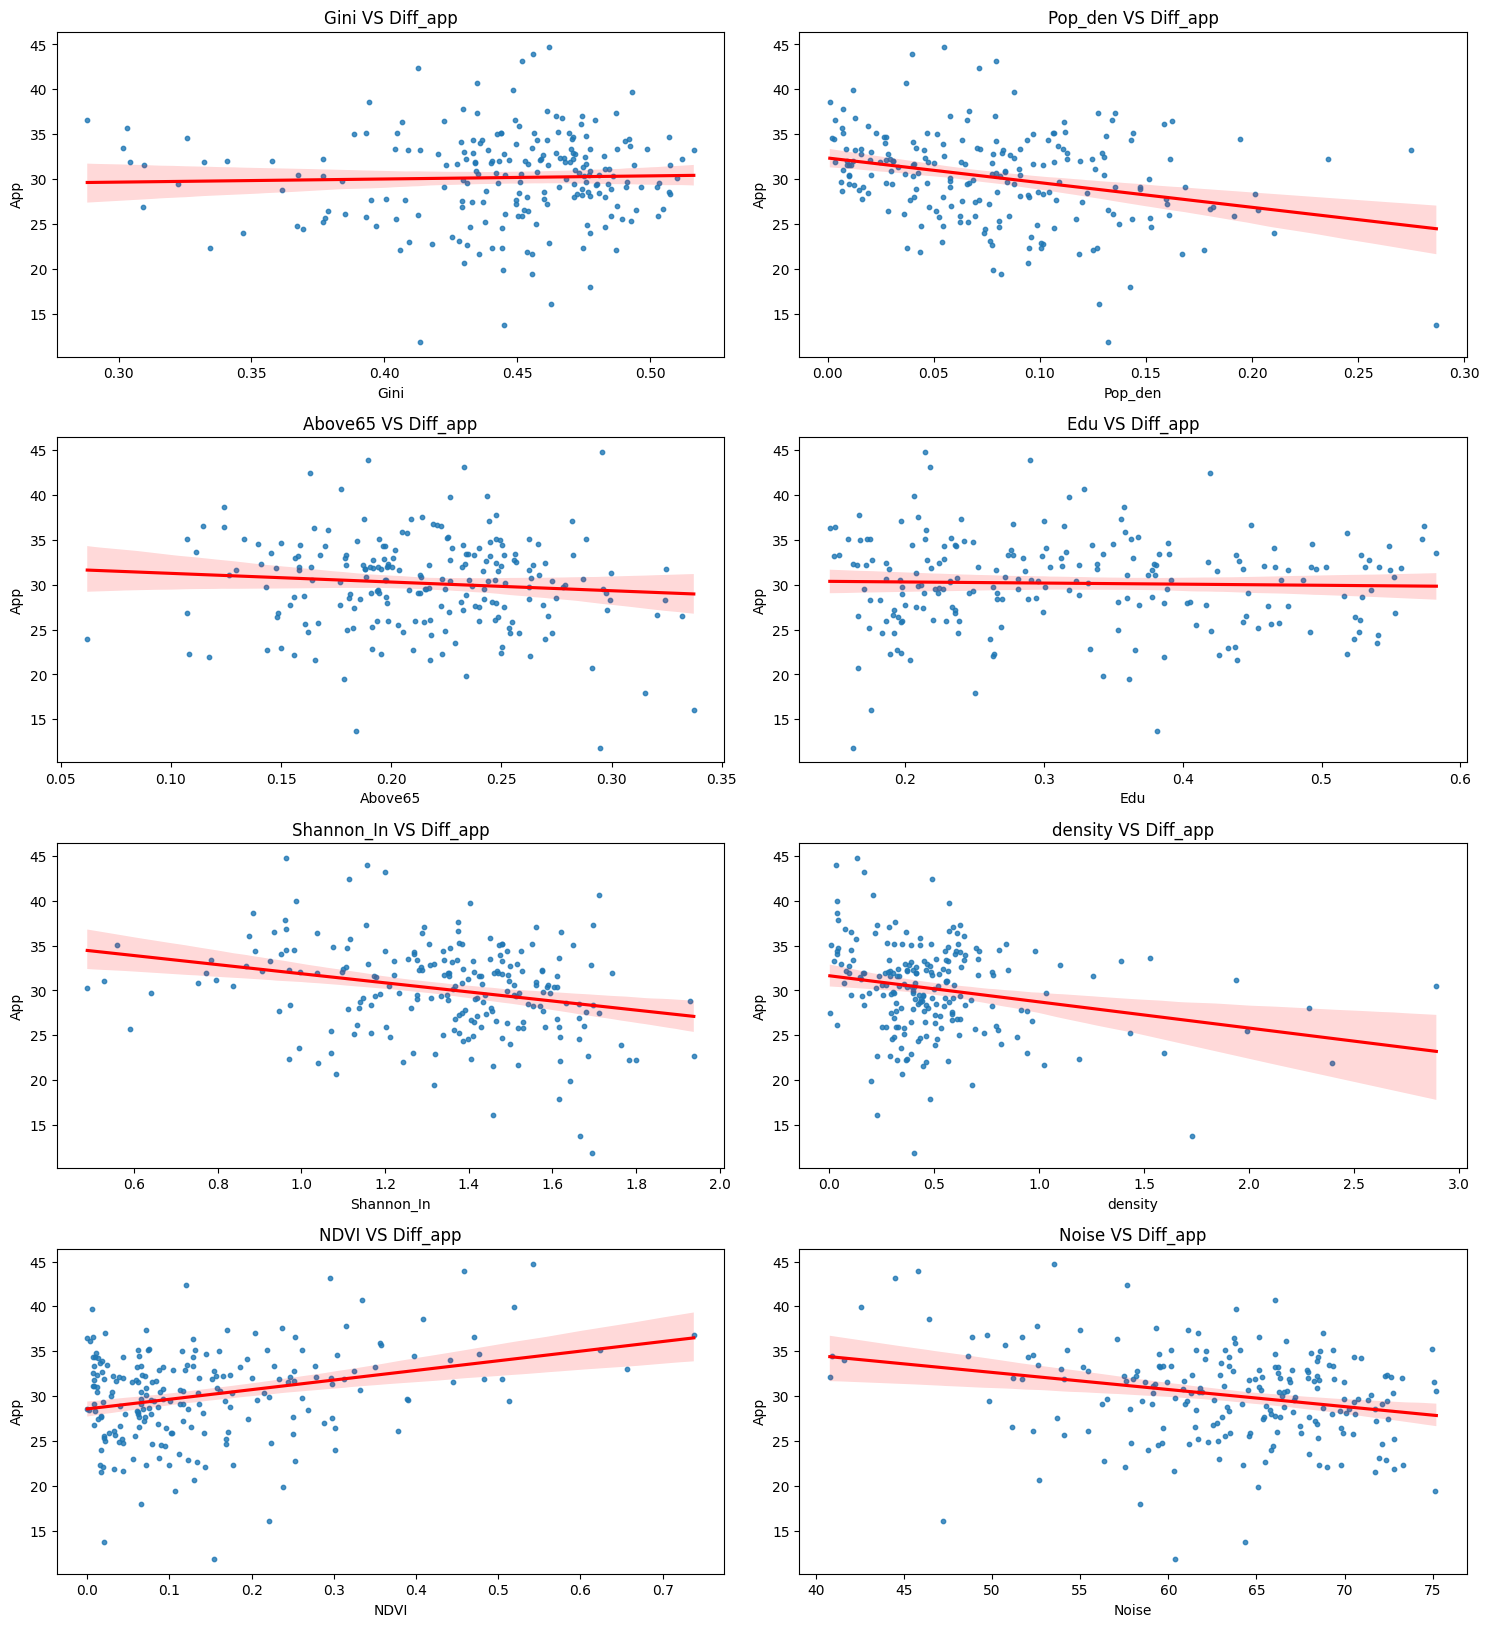

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

rows = 5
cols = 2

fig, axes = plt.subplots(rows, cols, figsize = (15, 20))
axes = axes.flatten()
for i, var in enumerate(variables):
    sns.regplot(x = result[var], y = result['App'], ax = axes[i], scatter_kws = {'s': 10}, line_kws = {'color': 'red'})
    axes[i].set_title(f'{var} VS Diff_app')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('App')

for i in range(len(variables), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.savefig('regplot_App.png', dpi=300) 
plt.show()

In [17]:
import statsmodels.api as sm
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import boxcox
from sklearn.preprocessing import StandardScaler

# 因变量 y
y = result['App']

# 对连续变量进行变换
result['density_transformed'] = np.log1p(result['density'])  # 对数变换
result['NDVI_transformed'] = np.log1p(result['NDVI'])  
result['Pop_transformed'] = np.log1p(result['Pop_den'])
result['Noise_transformed'], _ = boxcox(result['Noise'] + 1e-9)
result['Gini_transformed'], _ = boxcox(result['Gini'] + 1e-9)  # Box-Cox 变换
result['Building_type_binary'] = result['Building_type'].cat.codes

# 提取自变量
X = result[['Gini_transformed', 'Pop_transformed', 'Above65', 'Edu', 'Shannon_In',
            'density_transformed', 'NDVI_transformed', 'Building_type_binary', 'Noise_transformed']]

# 标准化连续变量
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# 添加常数项
X_scaled = sm.add_constant(X_scaled)

# 定义逐步回归函数
def stepwise_selection(X, y, 
                       initial_list=[], 
                       threshold_in=0.05, 
                       threshold_out=0.10, 
                       verbose=True):
    included = list(initial_list)
    while True:
        changed = False

        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index=excluded)
        for new_column in excluded:
            model = sm.OLS(y, sm.add_constant(X[included + [new_column]])).fit()
            new_pval[new_column] = model.pvalues[new_column]
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed = True
            if verbose:
                print(f"Add  {best_feature} with p-value {best_pval:.6}")


        model = sm.OLS(y, sm.add_constant(X[included])).fit()
        pvalues = model.pvalues.iloc[1:]  # exclude intercept
        worst_pval = pvalues.max()  # 最大P值
        if worst_pval > threshold_out:
            changed = True
            worst_feature = pvalues.idxmax()
            included.remove(worst_feature)
            if verbose:
                print(f"Drop {worst_feature} with p-value {worst_pval:.6}")

        if not changed:
            break

    return included, model

# 使用逐步回归选择变量
selected_features, final_model = stepwise_selection(X_scaled, y)
print("Selected features:", selected_features)

Add  const with p-value 3.02526e-169
Add  Pop_transformed with p-value 1.25106e-05
Add  Noise_transformed with p-value 0.000418616
Add  Gini_transformed with p-value 0.0176507
Add  Above65 with p-value 0.010767
Add  density_transformed with p-value 0.00349038
Add  Shannon_In with p-value 0.0284935
Selected features: ['const', 'Pop_transformed', 'Noise_transformed', 'Gini_transformed', 'Above65', 'density_transformed', 'Shannon_In']
